# Hierarchical Clustering Task

Use two Iris features, scale them, generate four dendrograms (single/complete x euclidean/cityblock), choose one, run agglomerative clustering, and verify with silhouette score.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler

# Load Iris CSV and keep only two features (unsupervised: no target variable)
df = pd.read_csv("Iris.csv")
X = df[["PetalLengthCm", "PetalWidthCm"]].to_numpy()
feature_names = ["PetalLengthCm", "PetalWidthCm"]

# Scale features
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Selected features:", feature_names)
print("Scaled data shape:", X_scaled.shape)

Selected features: ['PetalLengthCm', 'PetalWidthCm']
Scaled data shape: (150, 2)


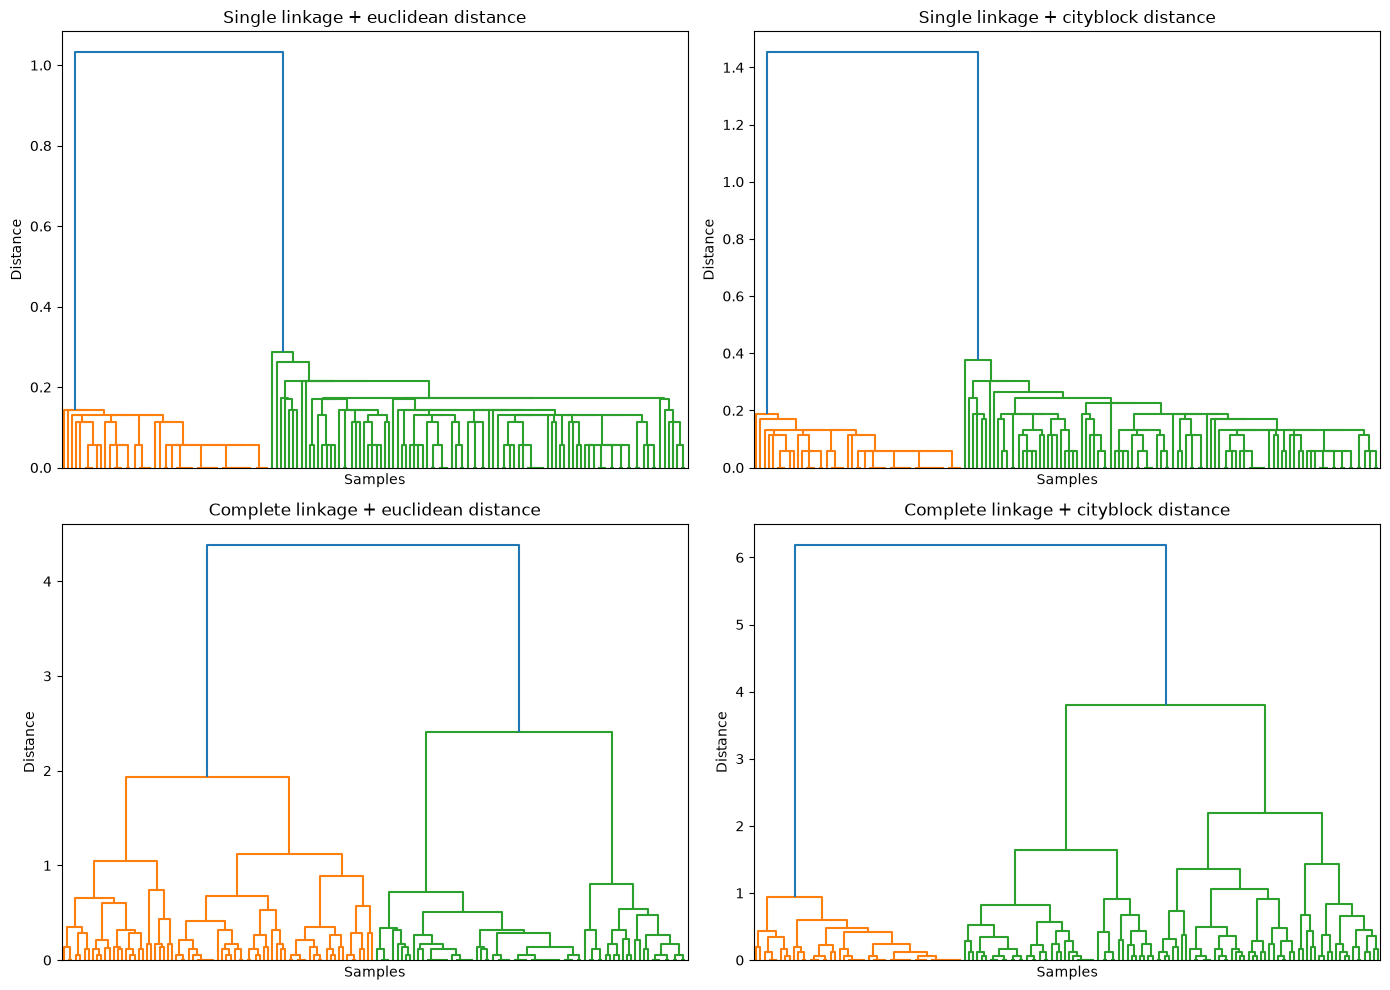

Chosen dendrogram for clustering: complete linkage + euclidean distance
Fixed number of clusters: 3


In [2]:
from scipy.cluster.hierarchy import linkage, dendrogram

configs = [
    ("single", "euclidean"),
    ("single", "cityblock"),
    ("complete", "euclidean"),
    ("complete", "cityblock"),
]

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

for ax, (method, metric) in zip(axes.flatten(), configs):
    Z = linkage(X_scaled, method=method, metric=metric)
    dendrogram(Z, ax=ax, no_labels=True, color_threshold=None)
    ax.set_title(f"{method.capitalize()} linkage + {metric} distance")
    ax.set_xlabel("Samples")
    ax.set_ylabel("Distance")

plt.tight_layout()
plt.show()

print("Chosen dendrogram for clustering: complete linkage + euclidean distance")
print("Fixed number of clusters: 3")

In [3]:
from sklearn.cluster import AgglomerativeClustering
from sklearn.metrics import silhouette_score

n_clusters = 3
chosen_linkage = "complete"
chosen_metric = "euclidean"

model = AgglomerativeClustering(
    n_clusters=n_clusters,
    linkage=chosen_linkage,
    metric=chosen_metric,
)
labels = model.fit_predict(X_scaled)

sil_score = silhouette_score(X_scaled, labels, metric=chosen_metric)
print(f"Silhouette score: {sil_score:.3f}")

if sil_score >= 0.5:
    confidence = "high"
elif sil_score >= 0.25:
    confidence = "moderate"
else:
    confidence = "low"

print(f"Confidence in clustering solution: {confidence}")
print("Comment: The silhouette score indicates how well-separated the clusters are.")

Silhouette score: 0.554
Confidence in clustering solution: high
Comment: The silhouette score indicates how well-separated the clusters are.
